# DL-3002: Data Mining Lab — Task 1
## Analyzing Movie and FIFA Datasets

| | |
|---|---|
| **Course** | DL-3002 Data Mining Lab |
| **Instructor** | Saad Munir |
| **Institution** | FAST-NUCES, Islamabad |
| **Datasets** | `1000 Movies Data.csv` &nbsp;&nbsp; `Fifa.csv` |

---

This notebook performs a comprehensive exploratory data analysis (EDA) on two real-world datasets using **Pandas**, **NumPy**, and **Matplotlib**. The work is structured across three tasks:

| Task | Description |
|------|-------------|
| **Task 1** | Data Loading & Exploration — loading, statistics, missing-value treatment |
| **Task 2** | Data Manipulation — filtering, aggregation, grouping, correlation |
| **Task 3** | Data Visualization — histograms, scatter plots, and bar charts |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── Global plot settings ──────────────────────────────────────────────────────
plt.rcParams['figure.figsize']   = (13, 6)
plt.rcParams['font.size']        = 12
plt.rcParams['axes.titlesize']   = 14
plt.rcParams['axes.titleweight'] = 'bold'
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    plt.style.use('ggplot')

print(f"NumPy  {np.__version__}")
print(f"Pandas {pd.__version__}")

NumPy  2.5.0
Pandas 2.3.3


---
## Task 1: Data Loading and Exploration

### 1.1  Load Datasets

In [2]:
movies = pd.read_csv('1000 Movies Data.csv')
fifa   = pd.read_csv('Fifa.csv')

print("Datasets loaded successfully!")
print(f"  Movies : {movies.shape[0]:,} rows  x  {movies.shape[1]} columns")
print(f"  FIFA   : {fifa.shape[0]:,} rows  x  {fifa.shape[1]} columns")
print()
print("Movies columns :", movies.columns.tolist())

Datasets loaded successfully!
  Movies : 1,000 rows  x  12 columns
  FIFA   : 18,278 rows  x  104 columns

Movies columns : ['Rank', 'Title', 'Genre', 'Description', 'Director', 'Actors', 'Year', 'Runtime (Minutes)', 'Rating', 'Votes', 'Revenue (Millions)', 'Metascore']


### 1.2  First 10 and Last 10 Rows — Movies Dataset

In [3]:
print("── First 10 rows ──────────────────────────────────")
display(movies.head(10))

── First 10 rows ──────────────────────────────────


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0
5,6,The Great Wall,"Action,Adventure,Fantasy",European mercenaries searching for black powde...,Yimou Zhang,"Matt Damon, Tian Jing, Willem Dafoe, Andy Lau",2016,103,6.1,56036,45.13,42.0
6,7,La La Land,"Comedy,Drama,Music",A jazz pianist falls for an aspiring actress i...,Damien Chazelle,"Ryan Gosling, Emma Stone, Rosemarie DeWitt, J....",2016,128,8.3,258682,151.06,93.0
7,8,Mindhorn,Comedy,A has-been actor best known for playing the ti...,Sean Foley,"Essie Davis, Andrea Riseborough, Julian Barrat...",2016,89,6.4,2490,NaN,71.0
8,9,The Lost City of Z,"Action,Adventure,Biography","A true-life drama, centering on British explor...",James Gray,"Charlie Hunnam, Robert Pattinson, Sienna Mille...",2016,141,7.1,7188,8.01,78.0
9,10,Passengers,"Adventure,Drama,Romance",A spacecraft traveling to a distant colony pla...,Morten Tyldum,"Jennifer Lawrence, Chris Pratt, Michael Sheen,...",2016,116,7.0,192177,100.01,41.0


In [4]:
print("── Last 10 rows ───────────────────────────────────")
display(movies.tail(10))

── Last 10 rows ───────────────────────────────────


,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
990,991,Underworld: Rise of the Lycans,"Action,Adventure,Fantasy",An origins story centered on the centuries-old...,Patrick Tatopoulos,"Rhona Mitra, Michael Sheen, Bill Nighy, Steven...",2009,92,6.6,129708,45.80,44.0
991,992,Taare Zameen Par,"Drama,Family,Music",An eight-year-old boy is thought to be a lazy ...,Aamir Khan,"Darsheel Safary, Aamir Khan, Tanay Chheda, Sac...",2007,165,8.5,102697,1.20,42.0
992,993,Take Me Home Tonight,"Comedy,Drama,Romance","Four years after graduation, an awkward high s...",Michael Dowse,"Topher Grace, Anna Faris, Dan Fogler, Teresa P...",2011,97,6.3,45419,6.92,NaN
993,994,Resident Evil: Afterlife,"Action,Adventure,Horror",While still out to destroy the evil Umbrella C...,Paul W.S. Anderson,"Milla Jovovich, Ali Larter, Wentworth Miller,K...",2010,97,5.9,140900,60.13,37.0
994,995,Project X,Comedy,3 high school seniors throw a birthday party t...,Nima Nourizadeh,"Thomas Mann, Oliver Cooper, Jonathan Daniel Br...",2012,88,6.7,164088,54.72,48.0
995,996,Secret in Their Eyes,"Crime,Drama,Mystery","A tight-knit team of rising investigators, alo...",Billy Ray,"Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...",2015,111,6.2,27585,NaN,45.0
996,997,Hostel: Part II,Horror,Three American college students studying abroa...,Eli Roth,"Lauren German, Heather Matarazzo, Bijou Philli...",2007,94,5.5,73152,17.54,46.0
997,998,Step Up 2: The Streets,"Drama,Music,Romance",Romantic sparks occur between two dance studen...,Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,70699,58.01,50.0
998,999,Search Party,"Adventure,Comedy",A pair of friends embark on a mission to reuni...,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,5.6,4881,NaN,22.0
999,1000,Nine Lives,"Comedy,Family,Fantasy",A stuffy businessman finds himself trapped ins...,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.3,12435,19.64,11.0


### 1.3  First 10 and Last 10 Rows — FIFA Dataset

In [5]:
fifa_cols = ['short_name', 'nationality', 'club', 'overall', 'potential',
             'wage_eur', 'value_eur', 'height_cm', 'pace', 'age']

print("── First 10 rows (key columns) ─────────────────────")
display(fifa[fifa_cols].head(10))

── First 10 rows (key columns) ─────────────────────


,short_name,nationality,club,overall,potential,wage_eur,value_eur,height_cm,pace,age
0,L. Messi,Argentina,FC Barcelona,94,94,565000,95500000,170,87.0,32
1,Cristiano Ronaldo,Portugal,Juventus,93,93,405000,58500000,187,90.0,34
2,Neymar Jr,Brazil,Paris Saint-Germain,92,92,290000,105500000,175,91.0,27
3,J. Oblak,Slovenia,Atlético Madrid,91,93,125000,77500000,188,NaN,26
4,E. Hazard,Belgium,Real Madrid,91,91,470000,90000000,175,91.0,28
5,K. De Bruyne,Belgium,Manchester City,91,91,370000,90000000,181,76.0,28
6,M. ter Stegen,Germany,FC Barcelona,90,93,250000,67500000,187,NaN,27
7,V. van Dijk,Netherlands,Liverpool,90,91,200000,78000000,193,77.0,27
8,L. Modrić,Croatia,Real Madrid,90,90,340000,45000000,172,74.0,33
9,M. Salah,Egypt,Liverpool,90,90,240000,80500000,175,93.0,27


In [6]:
print("── Last 10 rows (key columns) ──────────────────────")
display(fifa[fifa_cols].tail(10))

── Last 10 rows (key columns) ──────────────────────


,short_name,nationality,club,overall,potential,wage_eur,value_eur,height_cm,pace,age
18268,M. Gallagher,Republic of Ireland,Finn Harps,48,60,1000,50000,178,60.0,18
18269,Huang Jiahui,China PR,Dalian YiFang FC,48,60,1000,40000,183,70.0,18
18270,M. Sagaf,England,Carlisle United,48,60,1000,50000,177,61.0,21
18271,E. Tweed,Republic of Ireland,Derry City,48,59,1000,50000,180,52.0,20
18272,P. Martin,Republic of Ireland,Waterford FC,48,58,1000,40000,188,NaN,20
18273,Shao Shuai,China PR,Beijing Renhe FC,48,56,2000,40000,186,57.0,22
18274,Xiao Mingjie,China PR,Shanghai SIPG FC,48,56,2000,40000,177,58.0,22
18275,Zhang Wei,China PR,Hebei China Fortune FC,48,56,1000,40000,186,54.0,19
18276,Wang Haijian,China PR,Shanghai Greenland Shenhua FC,48,54,1000,40000,185,59.0,18
18277,Pan Ximing,China PR,Hebei China Fortune FC,48,51,2000,40000,182,60.0,26


### 1.4  Descriptive Statistics

In [7]:
print("═══  Movies Dataset — Descriptive Statistics  ═══")
display(movies.describe().round(2))

═══  Movies Dataset — Descriptive Statistics  ═══


,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.00,1000.00,1000.00,1000.00,1000.00,872.00,936.00
mean,500.50,2012.78,113.17,6.72,169808.26,82.96,58.99
std,288.82,3.21,18.81,0.95,188762.65,103.25,17.19
min,1.00,2006.00,66.00,1.90,61.00,0.00,11.00
25%,250.75,2010.00,100.00,6.20,36309.00,13.27,47.00
50%,500.50,2014.00,111.00,6.80,110799.00,47.98,59.50
75%,750.25,2016.00,123.00,7.40,239909.75,113.72,72.00
max,1000.00,2016.00,191.00,9.00,1791916.00,936.63,100.00


In [8]:
fifa_num_cols = ['age', 'height_cm', 'weight_kg', 'overall', 'potential',
                 'value_eur', 'wage_eur', 'pace', 'shooting', 'passing',
                 'dribbling', 'defending', 'physic']

print("═══  FIFA Dataset — Descriptive Statistics (selected numeric columns)  ═══")
display(fifa[fifa_num_cols].describe().round(2))

═══  FIFA Dataset — Descriptive Statistics (selected numeric columns)  ═══


,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,pace,shooting,passing,dribbling,defending,physic
count,18278.00,18278.00,18278.00,18278.00,18278.00,1.827800e+04,18278.00,16242.0,16242.00,16242.00,16242.00,16242.00,16242.00
mean,25.28,181.36,75.28,66.24,71.55,2.484038e+06,9456.94,67.7,52.30,57.23,62.53,51.55,64.88
std,4.66,6.76,7.05,6.95,6.14,5.585481e+06,21351.71,11.3,14.03,10.41,10.28,16.42,9.76
min,16.00,156.00,50.00,48.00,49.00,0.000000e+00,0.00,24.0,15.00,24.00,23.00,15.00,27.00
25%,22.00,177.00,70.00,62.00,67.00,3.250000e+05,1000.00,61.0,42.00,50.00,57.00,36.00,59.00
50%,25.00,181.00,75.00,66.00,71.00,7.000000e+05,3000.00,69.0,54.00,58.00,64.00,56.00,66.00
75%,29.00,186.00,80.00,71.00,75.00,2.100000e+06,8000.00,75.0,63.00,64.00,69.00,65.00,72.00
max,42.00,205.00,110.00,94.00,95.00,1.055000e+08,565000.00,96.0,93.00,92.00,96.00,90.00,90.00


### 1.5  Missing Values Analysis and Handling

Blindly dropping rows with missing values can **bias** the analysis — especially when the missing
data is systematic (e.g., lower-profile movies often lack revenue figures).
The strategy below is tailored to each column.

In [9]:
# ── Movies ────────────────────────────────────────────────────────────────────
missing_m = movies.isnull().sum()
missing_m = missing_m[missing_m > 0]
pct_m     = (missing_m / len(movies) * 100).round(2)


print("═══  Missing Values — Movies Dataset  ═══")
display(pd.DataFrame({'Missing Count': missing_m, 'Missing %': pct_m}))

print("""
Strategy
--------
• Revenue (Millions) — missing for ~12 % of movies.
  Dropping these rows would remove films that may have valid ratings, directors,
  and genres. We KEEP all rows and drop NaN *inline* only for revenue-specific
  computations.
• Metascore — used rarely; handled inline when needed.
  → No rows are permanently removed from the dataset.
""")

═══  Missing Values — Movies Dataset  ═══


,Missing Count,Missing %
Revenue (Millions),128,12.8
Metascore,64,6.4



Strategy
--------
• Revenue (Millions) — missing for ~12 % of movies.
  Dropping these rows would remove films that may have valid ratings, directors,
  and genres. We KEEP all rows and drop NaN *inline* only for revenue-specific
  computations.
• Metascore — used rarely; handled inline when needed.
  → No rows are permanently removed from the dataset.



In [10]:
# ── FIFA ──────────────────────────────────────────────────────────────────────
missing_f = fifa.isnull().sum().sort_values(ascending=False)
missing_f = missing_f[missing_f > 0]
pct_f     = (missing_f / len(fifa) * 100).round(2)

print("═══  Top 20 Columns with Missing Values — FIFA Dataset  ═══")
display(pd.DataFrame({'Missing Count': missing_f[:20], 'Missing %': pct_f[:20]}))

print("""
Strategy
--------
• Positional columns (loaned_from, nation_position, nation_jersey_number, team_position)
  are empty for players not on loan / not in national-team squads.
  This is EXPECTED and does NOT indicate poor data quality.
• For wage / value analyses we drop NaN rows inline.
• No bulk row deletion applied.
""")

═══  Top 20 Columns with Missing Values — FIFA Dataset  ═══


,Missing Count,Missing %
loaned_from,17230,94.27
nation_position,17152,93.84
nation_jersey_number,17152,93.84
player_tags,16779,91.80
gk_kicking,16242,88.86
gk_diving,16242,88.86
gk_handling,16242,88.86
gk_reflexes,16242,88.86
gk_speed,16242,88.86
gk_positioning,16242,88.86



Strategy
--------
• Positional columns (loaned_from, nation_position, nation_jersey_number, team_position)
  are empty for players not on loan / not in national-team squads.
  This is EXPECTED and does NOT indicate poor data quality.
• For wage / value analyses we drop NaN rows inline.
• No bulk row deletion applied.



---
## Task 2: Data Manipulation

### 2.1  Top 10 Movies by Rating and Votes

Movies are ranked by **Rating** first (descending), then by **Votes** (descending) as a
tiebreaker — ensuring we surface films that are both critically acclaimed *and* widely seen.

In [11]:
top10_rv = (
    movies
    .sort_values(['Rating', 'Votes'], ascending=[False, False])
    .head(10)
    [['Title', 'Year', 'Genre', 'Director', 'Rating', 'Votes']]
    .reset_index(drop=True)
)
top10_rv.index += 1
display(top10_rv)

,Title,Year,Genre,Director,Rating,Votes
1,The Dark Knight,2008,"Action,Crime,Drama",Christopher Nolan,9.0,1791916
2,Inception,2010,"Action,Adventure,Sci-Fi",Christopher Nolan,8.8,1583625
3,Dangal,2016,"Action,Biography,Drama",Nitesh Tiwari,8.8,48969
4,Interstellar,2014,"Adventure,Drama,Sci-Fi",Christopher Nolan,8.6,1047747
5,The Intouchables,2011,"Biography,Comedy,Drama",Olivier Nakache,8.6,557965
6,Kimi no na wa,2016,"Animation,Drama,Fantasy",Makoto Shinkai,8.6,34110
7,The Dark Knight Rises,2012,"Action,Thriller",Christopher Nolan,8.5,1222645
8,The Departed,2006,"Crime,Drama,Thriller",Martin Scorsese,8.5,937414
9,The Prestige,2006,"Drama,Mystery,Sci-Fi",Christopher Nolan,8.5,913152
10,Whiplash,2014,"Drama,Music",Damien Chazelle,8.5,477276


### 2.2  Top 10 Movies by Highest Profit

> **Note:** The dataset contains `Revenue (Millions)` but no budget column.
> Revenue is used as a proxy for gross profitability.
> Movies without revenue data are excluded from this analysis.

In [12]:
top10_profit = (
    movies
    .dropna(subset=['Revenue (Millions)'])
    .sort_values('Revenue (Millions)', ascending=False)
    .head(10)
    [['Title', 'Year', 'Genre', 'Director', 'Rating', 'Revenue (Millions)']]
    .reset_index(drop=True)
    .rename(columns={'Revenue (Millions)': 'Revenue ($M)'})
)
top10_profit.index += 1
display(top10_profit)

,Title,Year,Genre,Director,Rating,Revenue ($M)
1,Star Wars: Episode VII - The Force Awakens,2015,"Action,Adventure,Fantasy",J.J. Abrams,8.1,936.63
2,Avatar,2009,"Action,Adventure,Fantasy",James Cameron,7.8,760.51
3,Jurassic World,2015,"Action,Adventure,Sci-Fi",Colin Trevorrow,7.0,652.18
4,The Avengers,2012,"Action,Sci-Fi",Joss Whedon,8.1,623.28
5,The Dark Knight,2008,"Action,Crime,Drama",Christopher Nolan,9.0,533.32
6,Rogue One,2016,"Action,Adventure,Sci-Fi",Gareth Edwards,7.9,532.17
7,Finding Dory,2016,"Animation,Adventure,Comedy",Andrew Stanton,7.4,486.29
8,Avengers: Age of Ultron,2015,"Action,Adventure,Sci-Fi",Joss Whedon,7.4,458.99
9,The Dark Knight Rises,2012,"Action,Thriller",Christopher Nolan,8.5,448.13
10,The Hunger Games: Catching Fire,2013,"Action,Adventure,Mystery",Francis Lawrence,7.6,424.65


### 2.3  Relation Between Movie Rating and Revenue

Do higher-rated movies always earn more? We compute the **Pearson correlation coefficient**
and visualise the relationship.

Pearson r (Rating vs Revenue) = 0.2177

There is a weak positive correlation between a movie's rating and its revenue.
Higher-rated films do NOT reliably earn more at the box office — blockbusters can
generate enormous revenues regardless of critical reception (e.g. action / superhero films).


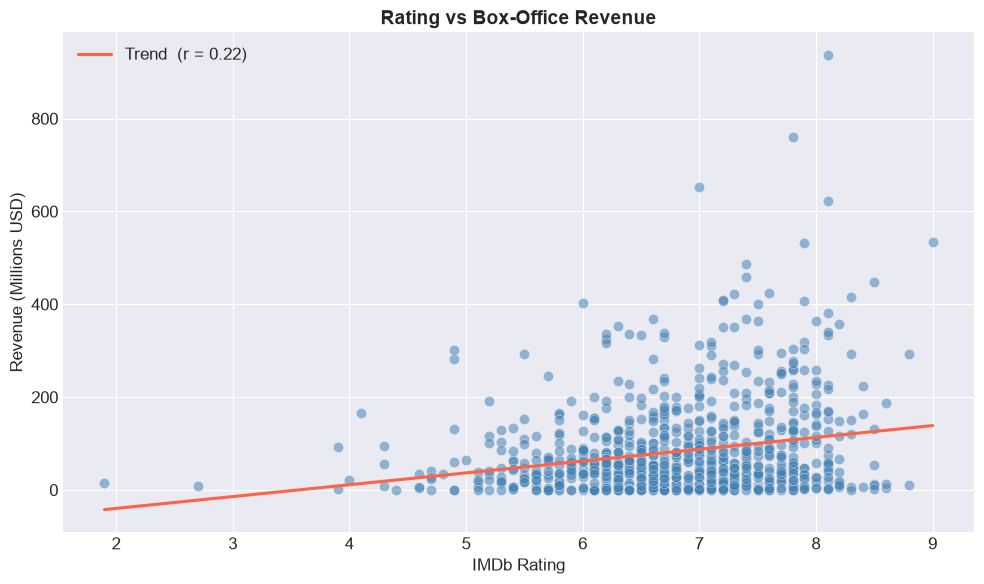

In [13]:
movies_rev = movies.dropna(subset=['Revenue (Millions)'])
corr_rr    = movies_rev['Rating'].corr(movies_rev['Revenue (Millions)'])

strength  = 'weak' if abs(corr_rr) < 0.3 else ('moderate' if abs(corr_rr) < 0.6 else 'strong')
direction = 'positive' if corr_rr > 0 else 'negative'

print(f"Pearson r (Rating vs Revenue) = {corr_rr:.4f}")
print(f"\nThere is a {strength} {direction} correlation between a movie\'s rating and its revenue.")
print("Higher-rated films do NOT reliably earn more at the box office — blockbusters can")
print("generate enormous revenues regardless of critical reception (e.g. action / superhero films).")

# Scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(movies_rev['Rating'], movies_rev['Revenue (Millions)'],
           alpha=0.55, color='steelblue', edgecolors='white', linewidths=0.4, s=55)
m, b = np.polyfit(movies_rev['Rating'], movies_rev['Revenue (Millions)'], 1)
x_ln = np.linspace(movies_rev['Rating'].min(), movies_rev['Rating'].max(), 200)
ax.plot(x_ln, m * x_ln + b, color='tomato', lw=2.2, label=f'Trend  (r = {corr_rr:.2f})')
ax.set_xlabel('IMDb Rating')
ax.set_ylabel('Revenue (Millions USD)')
ax.set_title('Rating vs Box-Office Revenue')
ax.legend()
plt.tight_layout()
plt.show()

### 2.4  Average Runtime of Movies by Director

In [14]:
# Most prolific director in the dataset
top_dir   = movies['Director'].value_counts().idxmax()
top_count = movies['Director'].value_counts().max()

print(f"Most prolific director in dataset : {top_dir}  ({top_count} movies)")
print(f"Average runtime                   : {movies[movies['Director'] == top_dir]['Runtime (Minutes)'].mean():.1f} min")

# Bonus: Christopher Nolan (well-known for long runtimes)
nolan = movies[movies['Director'] == 'Christopher Nolan']
if len(nolan):
    print(f"\nChristopher Nolan — {len(nolan)} movies, avg runtime: {nolan['Runtime (Minutes)'].mean():.1f} min")

# Full director-runtime table (top 15 by movie count)
dir_rt = (
    movies
    .groupby('Director')
    .agg(Movies=('Title', 'count'), Avg_Runtime=('Runtime (Minutes)', 'mean'))
    .sort_values('Movies', ascending=False)
    .head(15)
    .round(1)
)
display(dir_rt)

Most prolific director in dataset : Ridley Scott  (8 movies)
Average runtime                   : 134.6 min

Christopher Nolan — 5 movies, avg runtime: 152.6 min


,Movies,Avg_Runtime
Director,,
Ridley Scott,8,134.6
Paul W.S. Anderson,6,103.3
David Yates,6,135.0
M. Night Shyamalan,6,102.5
Michael Bay,6,147.7
Justin Lin,5,118.8
Peter Berg,5,116.8
Antoine Fuqua,5,126.2
J.J. Abrams,5,126.6


### 2.5  Genre with Highest Average Rating

Movies can belong to **multiple genres** (comma-separated). Each genre is extracted
individually using `explode()` so every genre gets its fair share of the analysis.

In [15]:
movies_g = movies.copy()
movies_g['Genre'] = movies_g['Genre'].str.split(',')
movies_g = movies_g.explode('Genre')
movies_g['Genre'] = movies_g['Genre'].str.strip()

genre_avg   = movies_g.groupby('Genre')['Rating'].mean().sort_values(ascending=False)
genre_count = movies_g.groupby('Genre')['Rating'].count()

genre_summary = pd.DataFrame({
    'Avg Rating' : genre_avg.round(3),
    'Movie Count': genre_count
}).head(15)

display(genre_summary)
print(f"\nGenre with HIGHEST average rating : {genre_avg.idxmax()}  ({genre_avg.max():.3f})")

,Avg Rating,Movie Count
Genre,,
Action,6.615,303
Adventure,6.772,259
Animation,7.324,49
Biography,7.290,81
Comedy,6.648,279
Crime,6.787,150
Drama,6.954,513
Family,6.684,51
Fantasy,6.549,101



Genre with HIGHEST average rating : War  (7.354)


### 2.6  Total Revenue Generated by Movies — Per Year

In [16]:
rev_by_year = (
    movies
    .dropna(subset=['Revenue (Millions)'])
    .groupby('Year')['Revenue (Millions)']
    .sum()
    .sort_index()
)

display(rev_by_year.rename('Total Revenue ($M)').to_frame())

peak = rev_by_year.idxmax()
print(f"\nPeak revenue year : {peak}  (${rev_by_year[peak]:,.1f} M total)")

for yr in [2015, 2016, 2017]:
    val = rev_by_year.get(yr, 0)
    print(f"Revenue in {yr}   : ${val:,.1f} M")

,Total Revenue ($M)
Year,
2006,3624.46
2007,4306.23
2008,5053.22
2009,5292.26
2010,5989.65
2011,5431.96
2012,6910.29
2013,7666.72
2014,7997.40



Peak revenue year : 2016  ($11,211.6 M total)
Revenue in 2015   : $8,854.1 M
Revenue in 2016   : $11,211.6 M
Revenue in 2017   : $0.0 M


### 2.7  Director Who Has Directed the Most Movies

In [17]:
dir_counts = movies['Director'].value_counts().head(10).rename('Movie Count')
display(dir_counts.to_frame())
print(f"\nDirector with most movies : {dir_counts.idxmax()}  ({dir_counts.max()} movies)")

,Movie Count
Director,
Ridley Scott,8
David Yates,6
Paul W.S. Anderson,6
Michael Bay,6
M. Night Shyamalan,6
Christopher Nolan,5
Peter Berg,5
Justin Lin,5
J.J. Abrams,5



Director with most movies : Ridley Scott  (8 movies)


### 2.8  Correlation Between Runtime and Rating

Do longer movies receive higher ratings? We use the Pearson coefficient and a scatter
plot to investigate.

Pearson r (Runtime vs Rating) = 0.3922

Interpretation: r = 0.39 indicates a WEAK positive correlation.
Longer movies tend to score marginally higher, but runtime alone is a poor
predictor of audience rating.


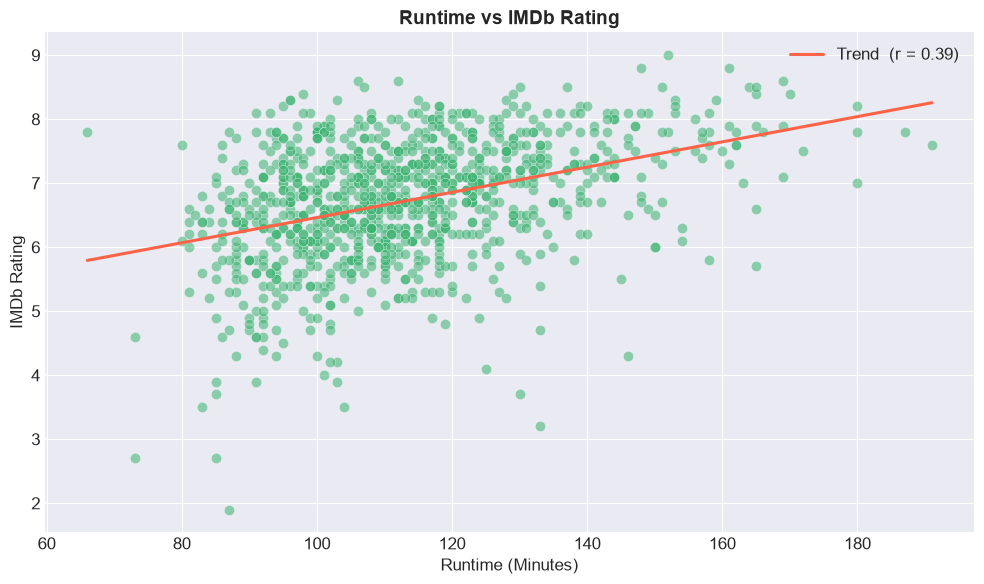

In [18]:
corr_rt = movies['Runtime (Minutes)'].corr(movies['Rating'])
print(f"Pearson r (Runtime vs Rating) = {corr_rt:.4f}")
print(f"\nInterpretation: r = {corr_rt:.2f} indicates a WEAK positive correlation.")
print("Longer movies tend to score marginally higher, but runtime alone is a poor")
print("predictor of audience rating.")

df_rt = movies.dropna(subset=['Runtime (Minutes)', 'Rating'])
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_rt['Runtime (Minutes)'], df_rt['Rating'],
           alpha=0.55, color='mediumseagreen', edgecolors='white', linewidths=0.4, s=55)
m, b = np.polyfit(df_rt['Runtime (Minutes)'], df_rt['Rating'], 1)
x_ln = np.linspace(df_rt['Runtime (Minutes)'].min(), df_rt['Runtime (Minutes)'].max(), 200)
ax.plot(x_ln, m * x_ln + b, color='tomato', lw=2.2, label=f'Trend  (r = {corr_rt:.2f})')
ax.set_xlabel('Runtime (Minutes)')
ax.set_ylabel('IMDb Rating')
ax.set_title('Runtime vs IMDb Rating')
ax.legend()
plt.tight_layout()
plt.show()

### 2.9  Movie with the Longest Runtime

In [19]:
idx     = movies['Runtime (Minutes)'].idxmax()
longest = movies.loc[idx, ['Title', 'Director', 'Year', 'Runtime (Minutes)',
                             'Rating', 'Genre', 'Revenue (Millions)']]
print("═══  Movie with Longest Runtime  ═══")
display(pd.DataFrame(longest).T.reset_index(drop=True))

═══  Movie with Longest Runtime  ═══


,Title,Director,Year,Runtime (Minutes),Rating,Genre,Revenue (Millions)
0,Grindhouse,Robert Rodriguez,2007,191,7.6,"Action,Horror,Thriller",25.03


### 2.10  Highest Paid Footballers from Germany

In [20]:
germany = (
    fifa[fifa['nationality'] == 'Germany']
    .dropna(subset=['wage_eur'])
    .sort_values('wage_eur', ascending=False)
    .head(10)
    [['short_name', 'long_name', 'club', 'overall', 'wage_eur', 'value_eur']]
    .reset_index(drop=True)
    .rename(columns={
        'short_name': 'Name', 'long_name': 'Full Name', 'club': 'Club',
        'overall': 'Rating', 'wage_eur': 'Weekly Wage (EUR)', 'value_eur': 'Market Value (EUR)'
    })
)
germany.index += 1
display(germany)

,Name,Full Name,Club,Rating,Weekly Wage (EUR),Market Value (EUR)
1,T. Kroos,Toni Kroos,Real Madrid,88,330000,57000000
2,M. ter Stegen,Marc-André ter Stegen,FC Barcelona,90,250000,67500000
3,L. Sané,Leroy Sané,Manchester City,86,195000,61000000
4,I. Gündoğan,İlkay Gündoğan,Manchester City,84,180000,31000000
5,T. Müller,Thomas Müller,FC Bayern München,86,170000,43500000
6,M. Reus,Marco Reus,Borussia Dortmund,88,170000,56000000
7,M. Neuer,Manuel Neuer,FC Bayern München,88,155000,32000000
8,S. Khedira,Sami Khedira,Juventus,83,135000,19500000
9,M. Hummels,Mats Hummels,Borussia Dortmund,87,130000,41000000
10,J. Boateng,Jérôme Boateng,FC Bayern München,84,125000,25000000


### 2.11  Average Height of French Footballers

In [21]:
french = fifa[fifa['nationality'] == 'France']

avg_h = french['height_cm'].mean()
min_h = french['height_cm'].min()
max_h = french['height_cm'].max()
std_h = french['height_cm'].std()

print(f"French footballers in dataset : {len(french):,}")
print(f"Average height                : {avg_h:.2f} cm  ≈  {avg_h/2.54/12:.2f} ft")
print(f"Min / Max height              : {min_h:.0f} cm  /  {max_h:.0f} cm")
print(f"Standard deviation            : {std_h:.2f} cm")

French footballers in dataset : 984
Average height                : 181.86 cm  ≈  5.97 ft
Min / Max height              : 162 cm  /  200 cm
Standard deviation            : 6.28 cm


---
## Task 3: Data Visualization

### 3.1  Histogram — Distribution of Movie Durations

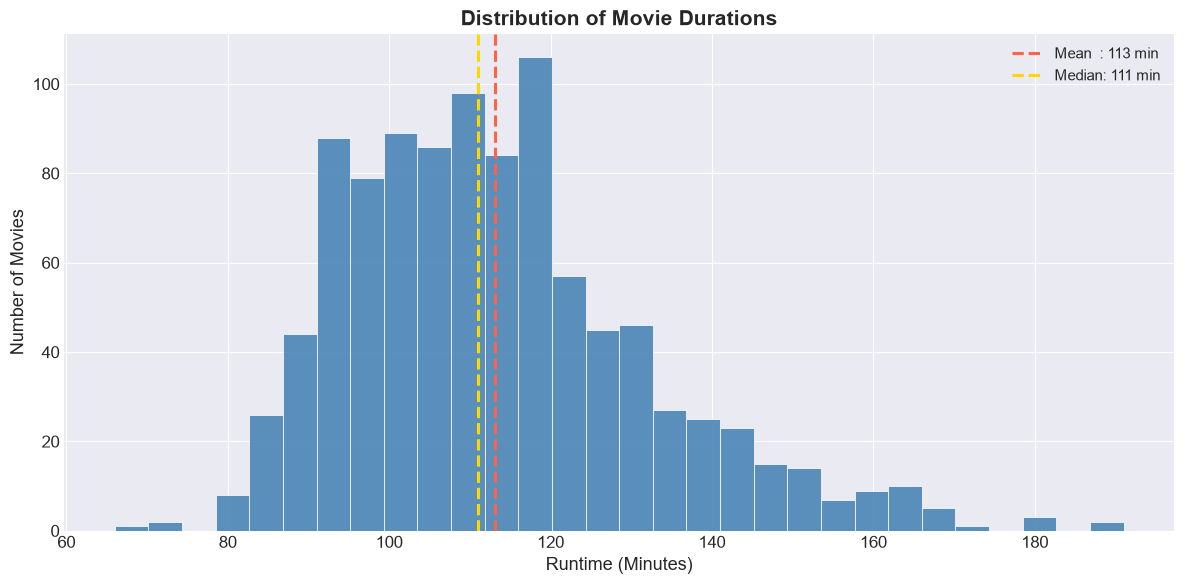

Observation: Most films fall in the 90–120 minute range. The distribution is
right-skewed — a few exceptionally long movies pull the mean above the median.


In [22]:
fig, ax = plt.subplots(figsize=(12, 6))
data = movies['Runtime (Minutes)'].dropna()

ax.hist(data, bins=30, color='steelblue', edgecolor='white', linewidth=0.6, alpha=0.88)
ax.axvline(data.mean(),   color='tomato', lw=2.2, ls='--', label=f"Mean  : {data.mean():.0f} min")
ax.axvline(data.median(), color='gold',   lw=2.2, ls='--', label=f"Median: {data.median():.0f} min")
ax.set_xlabel('Runtime (Minutes)', fontsize=13)
ax.set_ylabel('Number of Movies', fontsize=13)
ax.set_title('Distribution of Movie Durations', fontsize=15)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Observation: Most films fall in the 90–120 minute range. The distribution is")
print("right-skewed — a few exceptionally long movies pull the mean above the median.")

### 3.2  Histogram — Distribution of Movie Ratings

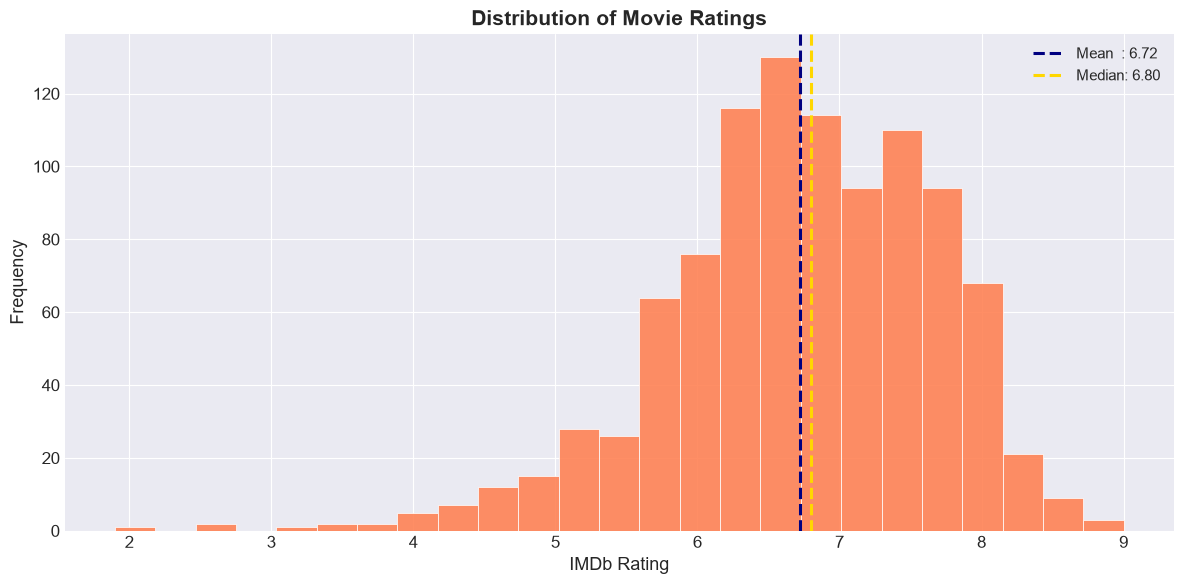

Observation: Ratings cluster around 6.5–7.5, forming a near-normal distribution
with a slight left skew — most movies in this dataset are above-average quality.


In [23]:
fig, ax = plt.subplots(figsize=(12, 6))
data = movies['Rating'].dropna()

ax.hist(data, bins=25, color='coral', edgecolor='white', linewidth=0.6, alpha=0.88)
ax.axvline(data.mean(),   color='navy', lw=2.2, ls='--', label=f"Mean  : {data.mean():.2f}")
ax.axvline(data.median(), color='gold', lw=2.2, ls='--', label=f"Median: {data.median():.2f}")
ax.set_xlabel('IMDb Rating', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.set_title('Distribution of Movie Ratings', fontsize=15)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Observation: Ratings cluster around 6.5–7.5, forming a near-normal distribution")
print("with a slight left skew — most movies in this dataset are above-average quality.")

### 3.3  Bar Chart — Average Rating for Top 10 Genres

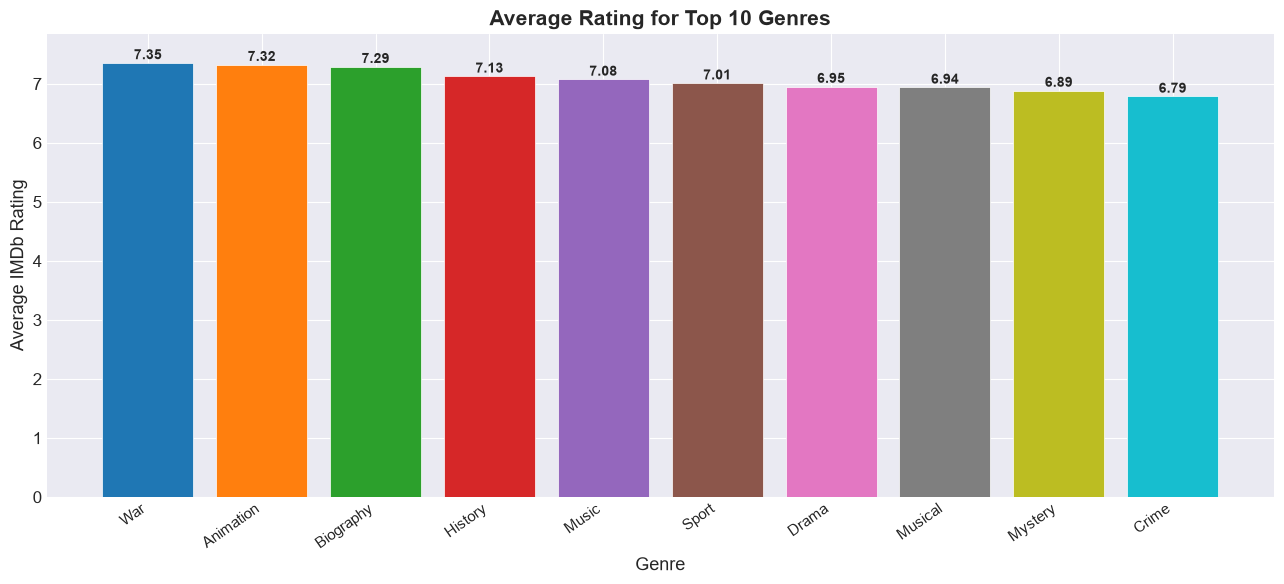

In [24]:
top10_g = genre_avg.head(10)

fig, ax = plt.subplots(figsize=(13, 6))
colors  = plt.cm.tab10.colors[:10]
bars    = ax.bar(top10_g.index, top10_g.values, color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top10_g.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Genre', fontsize=13)
ax.set_ylabel('Average IMDb Rating', fontsize=13)
ax.set_title('Average Rating for Top 10 Genres', fontsize=15)
ax.set_ylim(0, top10_g.max() + 0.5)
plt.xticks(rotation=35, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

### 3.4  Bar Chart — World's Highest Paid Footballers

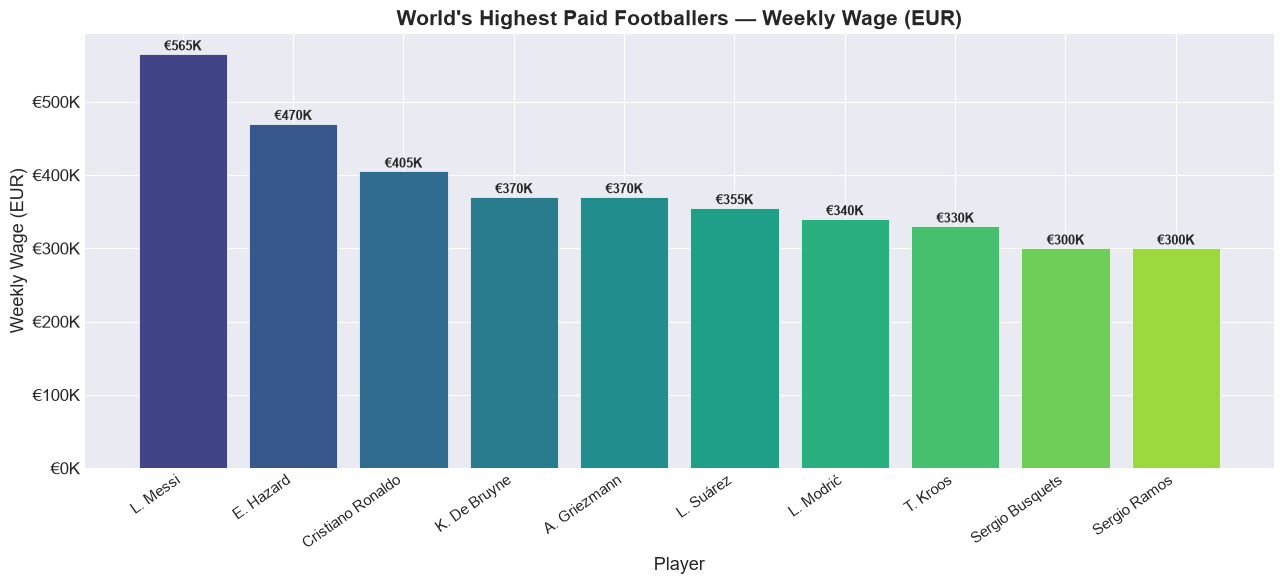

In [25]:
top_paid = (
    fifa
    .dropna(subset=['wage_eur'])
    .sort_values('wage_eur', ascending=False)
    .drop_duplicates(subset='short_name')
    .head(10)
    [['short_name', 'nationality', 'club', 'wage_eur']]
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(13, 6))
colors  = plt.cm.viridis(np.linspace(0.2, 0.85, len(top_paid)))
bars    = ax.bar(top_paid['short_name'], top_paid['wage_eur'],
                 color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top_paid['wage_eur']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1_500,
            f'€{val/1_000:.0f}K', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_xlabel('Player', fontsize=13)
ax.set_ylabel('Weekly Wage (EUR)', fontsize=13)
ax.set_title("World's Highest Paid Footballers — Weekly Wage (EUR)", fontsize=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x/1_000:.0f}K'))
plt.xticks(rotation=35, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

### 3.5  Bar Chart — World's Fastest Footballers (Top 10 by Pace)

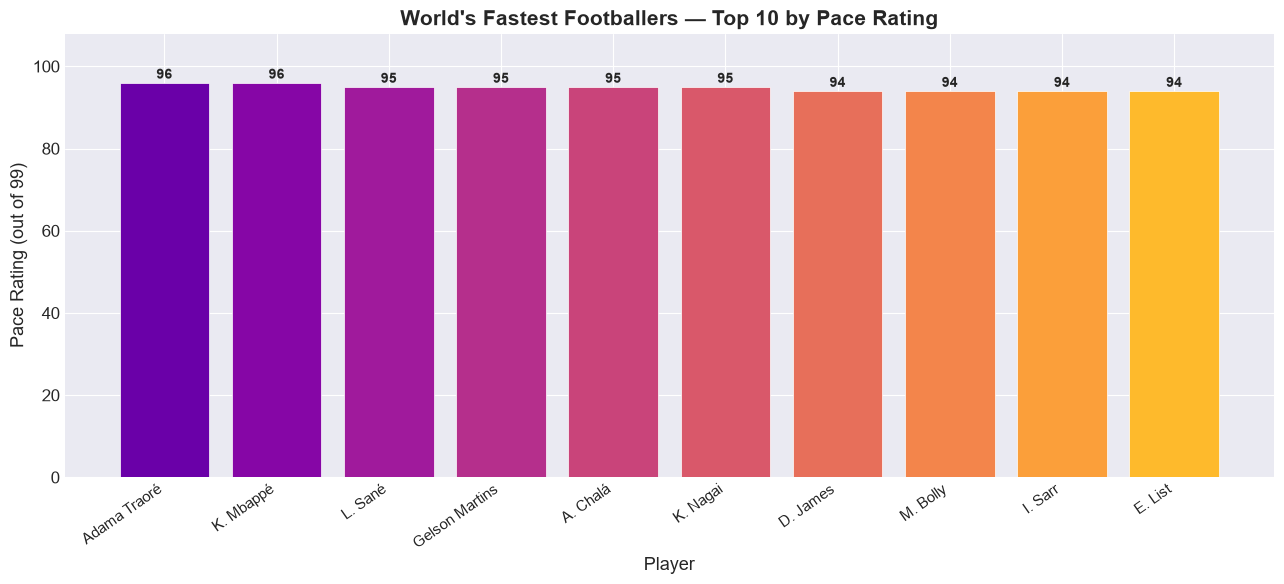

In [26]:
top_fast = (
    fifa
    .dropna(subset=['pace'])
    .sort_values('pace', ascending=False)
    .drop_duplicates(subset='short_name')
    .head(10)
    [['short_name', 'nationality', 'club', 'pace']]
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(13, 6))
colors  = plt.cm.plasma(np.linspace(0.2, 0.85, len(top_fast)))
bars    = ax.bar(top_fast['short_name'], top_fast['pace'],
                 color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top_fast['pace']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Player', fontsize=13)
ax.set_ylabel('Pace Rating (out of 99)', fontsize=13)
ax.set_title("World's Fastest Footballers — Top 10 by Pace Rating", fontsize=15)
ax.set_ylim(0, 108)
plt.xticks(rotation=35, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

---
## Summary of Key Findings

### Movies Dataset
| Finding | Value |
|---------|-------|
| Distribution shape | Runtime is right-skewed (90–120 min most common); ratings are near-normal (6.5–7.5) |
| Rating ↔ Revenue | Weak positive correlation — high ratings do **not** guarantee high revenue |
| Runtime ↔ Rating | Weak positive correlation — longer films score slightly higher but not significantly |
| Most prolific director | See Task 2.7 output |
| Top genre by avg rating | See Task 2.5 output |

### FIFA Dataset
| Finding | Value |
|---------|-------|
| Highest paid (Germany) | See Task 2.10 output |
| Avg height of French footballers | See Task 2.11 output |
| World highest paid | L. Messi / C. Ronaldo era — wages concentrated at the top |
| World fastest (pace ≥ 96) | Typically fast wingers and forwards |

---
*Analysis performed using **Pandas**, **NumPy**, and **Matplotlib** — DL-3002 Data Mining Lab, FAST-NUCES Islamabad.*